In [8]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import numpy as np
from glob import glob
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
%matplotlib inline

subplot_kws=dict(projection=ccrs.PlateCarree(central_longitude=180))

In [9]:
dataDir='/data/mileshsieh/CMIP6'
m='TaiESM1'
scenarios=['historical','ssp126','ssp245','ssp370','ssp585']

template='%s/%s/%s/atmos/day/r1i1p1f1/%s_day_%s_%s_r1i1p1f1_gn_%04d0101-*.nc'
#varList=['psl','ua','va']
varList=['psl',]

In [10]:
[min_lon, max_lon, min_lat, max_lat]=[90.,170.,10.,70.]
#p_selected=850
#yrDict={'historical':1990,'ssp585':2075}
yrDict={'historical':[1990,'1991-01-01','2010-12-31'],'ssp585':[2075,'2081-01-01','2100-12-31']} #[start yr of files,stat_start_date,stat_end_date]

dsDict={}
#open mfdataset (multiple files dataset)
for sce in yrDict.keys():
    yr_start=yrDict[sce][0]
    #open multiple files
    fList=[glob(template%(dataDir,m,sce,var,m,sce,yr_start))[0] for var in varList]\
         +[glob(template%(dataDir,m,sce,var,m,sce,yr_start+10))[0] for var in varList]\
         +[glob(template%(dataDir,m,sce,var,m,sce,yr_start+20))[0] for var in varList]
    print(fList)
    #open multiple files
    dsDict[sce]=xr.open_mfdataset(fList).sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon),time=slice(yrDict[sce][1], yrDict[sce][2]),)

['/data/mileshsieh/CMIP6/TaiESM1/historical/atmos/day/r1i1p1f1/psl_day_TaiESM1_historical_r1i1p1f1_gn_19900101-19991231.nc', '/data/mileshsieh/CMIP6/TaiESM1/historical/atmos/day/r1i1p1f1/psl_day_TaiESM1_historical_r1i1p1f1_gn_20000101-20091231.nc', '/data/mileshsieh/CMIP6/TaiESM1/historical/atmos/day/r1i1p1f1/psl_day_TaiESM1_historical_r1i1p1f1_gn_20100101-20141231.nc']
['/data/mileshsieh/CMIP6/TaiESM1/ssp585/atmos/day/r1i1p1f1/psl_day_TaiESM1_ssp585_r1i1p1f1_gn_20750101-20841231.nc', '/data/mileshsieh/CMIP6/TaiESM1/ssp585/atmos/day/r1i1p1f1/psl_day_TaiESM1_ssp585_r1i1p1f1_gn_20850101-20941231.nc', '/data/mileshsieh/CMIP6/TaiESM1/ssp585/atmos/day/r1i1p1f1/psl_day_TaiESM1_ssp585_r1i1p1f1_gn_20950101-21001231.nc']


In [11]:
dsDict['historical'].sel(time=(dsDict['historical'].time.dt.month==10)).mean(dim='time')

<xarray.Dataset>
Dimensions:   (lat: 63, bnds: 2, lon: 65)
Coordinates:
  * lat       (lat) float64 10.84 11.78 12.72 13.66 ... 66.44 67.38 68.32 69.27
  * lon       (lon) float64 90.0 91.25 92.5 93.75 ... 166.2 167.5 168.8 170.0
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (lat, bnds) float64 dask.array<chunksize=(63, 2), meta=np.ndarray>
    lon_bnds  (lon, bnds) float64 dask.array<chunksize=(65, 2), meta=np.ndarray>
    psl       (lat, lon) float32 dask.array<chunksize=(63, 65), meta=np.ndarray>

In [12]:
lat=dsDict['historical'].lat.values
lon=dsDict['historical'].lon.values
print(lat[1:]-lat[:-1])
print(lon[1:]-lon[:-1])

[0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838 0.94240838
 0.94240838 0.94240838]
[1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1

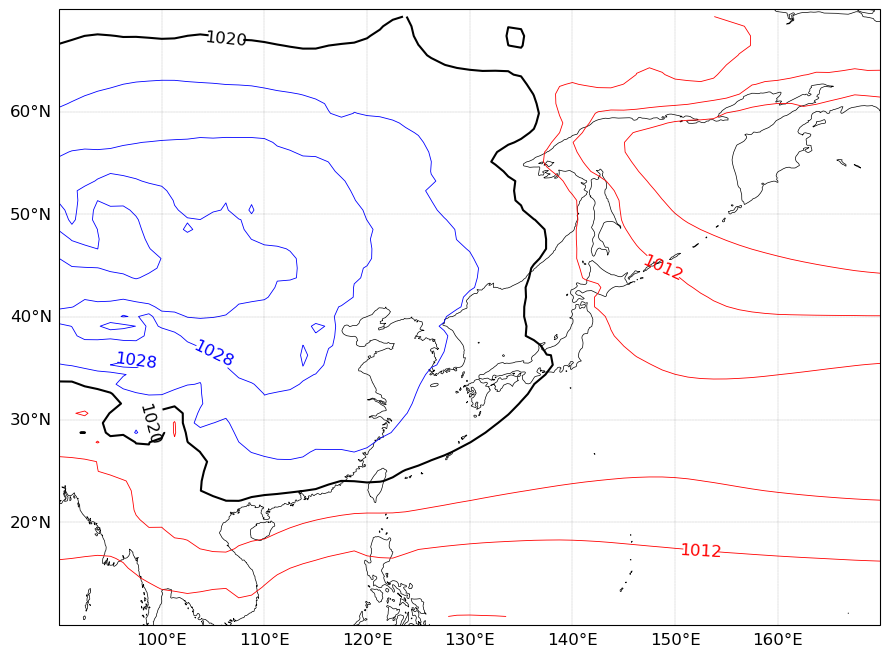

In [8]:
#single plot of historical
sce='historical'
mon=12

ds_plot=dsDict['historical'].sel(time=(dsDict[sce].time.dt.month==mon)).mean(dim='time')
msl=ds_plot.psl/100
msl.attrs = ds_plot.psl.attrs
msl.attrs['units']='hPa'
# Defining the figure
fig = plt.figure(figsize=(16,8), facecolor='w', edgecolor='k')

# Axes with Cartopy projection
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
# and extent
ax.set_extent([min_lon, max_lon, min_lat, max_lat], ccrs.PlateCarree())

# Plotting using Matplotlib the mean current
cs = msl.plot.contour(subplot_kws=subplot_kws,transform=ccrs.PlateCarree(),
                      levels=[1008,1012,1016,1020,1024,1028,1032,1036],
                      colors=['red','red','red','k','blue','blue','blue','blue'],
                      linewidths=[0.6,0.6,0.6,1.5,0.6,0.6,0.6,0.6])
ax.clabel(cs, [1012,1020,1028], inline=True, fmt='%.0f', fontsize=12)
#q1=ds_plot.plot.quiver(x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(), scale=80,color='g')
ax.coastlines(resolution='50m',linewidth=0.5)
# Plot lat/lon grid 
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12} 

# Vector options declaration
#veclenght = 0.5
#maxstr = '%3.1f m/s' % veclenght
#plt.quiverkey(q1,0.8,0.9,veclenght,maxstr,labelpos='E', coordinates='figure').set_zorder(11)


In [35]:
mon=2

dateList=pd.read_csv('./ishigaki.wind1000.TaiESM1.historical.mon02.19910101to20101231.csv').query('wdCor<75.0').date.values
print(len(dateList),dateList[:10])
print(dsDict['historical'].time[0],dsDict['historical'].time[-1])
dsDict['historical'].sel(time=dsDict['historical'].time.dt.strftime('%Y-%m-%d %H:%M:%S').isin(dateList))

498 ['1991-02-01 12:00:00' '1991-02-02 12:00:00' '1991-02-03 12:00:00'
 '1991-02-04 12:00:00' '1991-02-05 12:00:00' '1991-02-06 12:00:00'
 '1991-02-07 12:00:00' '1991-02-08 12:00:00' '1991-02-09 12:00:00'
 '1991-02-10 12:00:00']
<xarray.DataArray 'time' ()>
array(cftime.DatetimeNoLeap(1991, 1, 1, 12, 0, 0, 0, has_year_zero=True),
      dtype=object)
Coordinates:
    time     object 1991-01-01 12:00:00
Attributes:
    bounds:         time_bnds
    axis:           T
    long_name:      time
    standard_name:  time <xarray.DataArray 'time' ()>
array(cftime.DatetimeNoLeap(2010, 12, 31, 12, 0, 0, 0, has_year_zero=True),
      dtype=object)
Coordinates:
    time     object 2010-12-31 12:00:00
Attributes:
    bounds:         time_bnds
    axis:           T
    long_name:      time
    standard_name:  time


<xarray.Dataset>
Dimensions:    (time: 498, bnds: 2, lat: 63, lon: 65)
Coordinates:
  * time       (time) object 1991-02-01 12:00:00 ... 2010-02-28 12:00:00
  * lat        (lat) float64 10.84 11.78 12.72 13.66 ... 66.44 67.38 68.32 69.27
  * lon        (lon) float64 90.0 91.25 92.5 93.75 ... 166.2 167.5 168.8 170.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object dask.array<chunksize=(227, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 dask.array<chunksize=(227, 63, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 dask.array<chunksize=(227, 65, 2), meta=np.ndarray>
    psl        (time, lat, lon) float32 dask.array<chunksize=(227, 63, 65), meta=np.ndarray>
Attributes: (12/50)
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    branch_method:             Hybrid-restart from year 0671-01-01 of piControl
    branch_time:               0.0
    branch_time_in_child:      0.0
    branch_time_in_parent:     171550.0
    ...                        ...
    title:                     TaiESM1 output prepared for CMIP6
    variable_id:               psl
    variant_label:             r1i1p1f1
    license:                   CMIP6 model data produced by NCC is licensed u...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/cb725f5c-011b-4cfa-92a3-2531a1165519

498 498
480 480


FileNotFoundError: [Errno 2] No such file or directory: './figures/comp_msl.mon02.png'

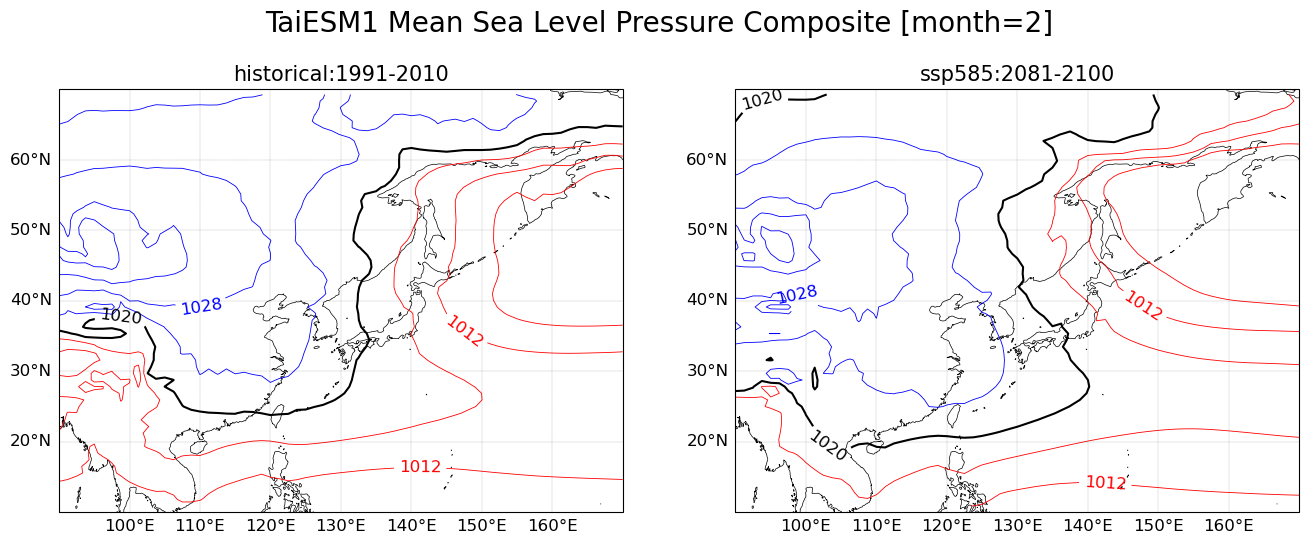

In [40]:
[min_lon, max_lon, min_lat, max_lat]=[90.,170.,10.,70.]

#for mon in [1,2,3,4,10,11,12]:
for mon in [2,]:
    #get dateList
    dateList={'historical':pd.read_csv('./ishigaki.wind1000.TaiESM1.historical.mon%02d.19910101to20101231.csv'%mon).query('wdCor<75.0').date.values,
              'ssp585':pd.read_csv('./ishigaki.wind1000.TaiESM1.ssp585.mon%02d.20810101to21001231.csv'%mon).query('wdCor<75.0').date.values}
    
    plt.close()
    fig,axes = plt.subplots(1, 2,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},figsize=(16,6), facecolor='w', edgecolor='k')
    for ax,prd in zip(axes,['historical','ssp585']):
        #ds_plot=dsDict[prd].sel(time=(dsDict[prd].time.dt.month==mon)).mean(dim='time')
        ds_temp=dsDict[prd].sel(time=dsDict[prd].time.dt.strftime('%Y-%m-%d %H:%M:%S').isin(dateList[prd]))
        print(dateList[prd].shape[0],ds_temp.time.shape[0])

        ds_plot=ds_temp.mean(dim='time')
        msl=ds_plot.psl/100
        msl.attrs = ds_plot.psl.attrs
        msl.attrs['units']='hPa'
        
        ax.set_extent([min_lon, max_lon, min_lat, max_lat], ccrs.PlateCarree())
        # Plotting using Matplotlib the mean current
        cs = msl.plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=[1008,1012,1016,1020,1024,1028,1032,1036],
                      colors=['red','red','red','k','blue','blue','blue','blue'],
                      linewidths=[0.6,0.6,0.6,1.5,0.6,0.6,0.6,0.6])
        ax.clabel(cs, [1012,1020,1028], inline=True, fmt='%.0f', fontsize=12)
        ax.coastlines(resolution='50m',linewidth=0.5)
        ax.set_title('%s:%s-%s'%(prd,yrDict[prd][1][:4],yrDict[prd][2][:4]),fontsize=15)
        # Plot lat/lon grid 
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=0.1, color='k', alpha=1, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = {'size': 12}
        gl.ylabel_style = {'size': 12} 
    #plt.tight_layout()
    plt.suptitle('TaiESM1 Mean Sea Level Pressure Composite [month=%d]'%mon,fontsize=20)
    plt.savefig('./figures/comp_msl.mon%02d.png'%mon,dpi=300)
